In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


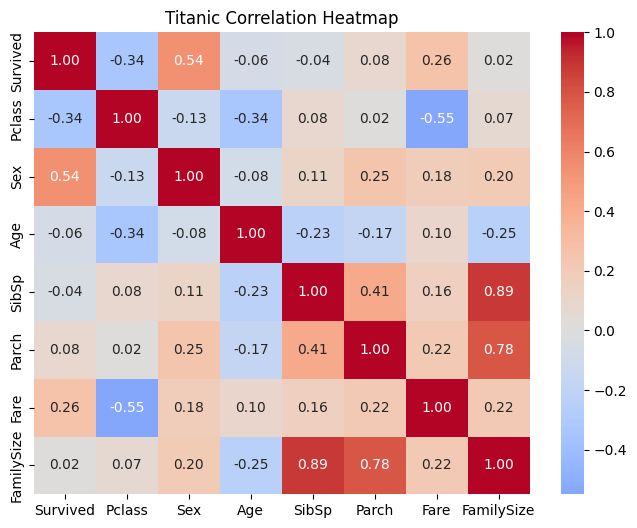

In [12]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df = train.copy()


df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Titanic Correlation Heatmap')
plt.show() 

In [18]:
df_model = train.copy()  # fresh copy from original, untouched train
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})  # encode sex as 0/1
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())  # fill missing age with median
df_model['Embarked'] = df_model['Embarked'].fillna(df_model['Embarked'].mode()[0])  # fill missing embarked with most common
df_model['Embarked'] = df_model['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})  # encode embarked as numbers

df_model['Title'] = df_model['Name'].str.extract(r',\s*([^\.]+)\.')  # extract title from name
df_model['Title'] = df_model['Title'].replace(['Dr','Rev','Col','Major','Countess','Lady','Jonkheer','Don','Capt','Sir'], 'Rare')
df_model['Title'] = df_model['Title'].replace(['Mlle','Ms'], 'Miss').replace('Mme', 'Mrs')
df_model['Title'] = df_model['Title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Rare':4})
df_model['Title'] = df_model['Title'].fillna(4)  # catch-all: any unmapped title becomes Rare (4)

df_model['FamilySize'] = df_model['SibSp'] + df_model['Parch'] + 1  # combine family columns

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize']
X = df_model[features]
y = df_model['Survived']

model = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=6, random_state=42)  
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"{scores.mean() * 100:.2f}%")

84.40%


In [20]:
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")  # load test data

df_test = test.copy()  # never touch original test
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})  # encode sex as 0/1
df_test['Age'] = df_test['Age'].fillna(df_model['Age'].median())  # fill using TRAIN median, not test's own
df_test['Fare'] = df_test['Fare'].fillna(df_model['Fare'].median())  # test has 1 missing Fare, fill using train median
df_test['Embarked'] = df_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})  # encode embarked as numbers

df_test['Title'] = df_test['Name'].str.extract(r',\s*([^\.]+)\.')  # extract title from name
df_test['Title'] = df_test['Title'].replace(['Dr','Rev','Col','Major','Countess','Lady','Jonkheer','Don','Capt','Sir'], 'Rare')
df_test['Title'] = df_test['Title'].replace(['Mlle','Ms'], 'Miss').replace('Mme', 'Mrs')
df_test['Title'] = df_test['Title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Rare':4})
df_test['Title'] = df_test['Title'].fillna(4)  # catch-all for unmapped titles

df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1  # combine family columns

X_test_final = df_test[features]  # same feature columns as training

model.fit(X, y)  # train final model on ALL of train.csv (no more splitting/holding out)
predictions = model.predict(X_test_final)  # predict survival on test.csv

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)  # save in Kaggle's required format

print("submission.csv saved!")
submission.head()

submission.csv saved!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
